# Population Growth Analysis — Final Submission Notebook

This notebook completes the full project workflow in one place: data audit, cleaning, reshaping, exploratory data analysis, advanced analysis, visualizations, and forecasting.

**Important note:** the source file is a UN population indicators dataset. It does **not** contain a single direct country total-population series, so the notebook focuses on the available growth indicators such as **Population Change** and **Rate of population change**. To make the project rubric-friendly, I also add a continent/region grouping column and a clear limitations section.


In [5]:
import os
import glob
import re
import warnings
from functools import lru_cache
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

# Optional packages for continent mapping
try:
    import pycountry
except:
    !pip install -q pycountry
    import pycountry

try:
    from countryinfo import CountryInfo
except:
    !pip install -q countryinfo
    from countryinfo import CountryInfo

plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11
})

ROOT_CANDIDATES = [
    "/kaggle/input/datasets/anishkhobragade16/un-population-dataset-1990-2026",
    "/kaggle/input",
    "/mnt/data"
]
KAGGLE_ROOT = next((p for p in ROOT_CANDIDATES if os.path.exists(p)), "/mnt/data")
OUTDIR = "/kaggle/working/population_project_outputs" if os.path.exists("/kaggle/working") else "/mnt/data/population_project_outputs"
os.makedirs(OUTDIR, exist_ok=True)

def find_data_file(root):
    patterns = ["*.csv", "*.xlsx", "*.xls"]
    candidates = []
    for p in patterns:
        candidates.extend(glob.glob(os.path.join(root, "**", p), recursive=True))
    if not candidates:
        raise FileNotFoundError(f"No CSV/XLSX file found under: {root}")

    def score(path):
        name = os.path.basename(path).lower()
        s = 0
        if "unpopulation" in name:
            s += 1000
        if "dataportal" in name:
            s += 500
        if "population" in name:
            s += 100
        if name.endswith(".csv"):
            s += 10
        # Larger files are more likely to be the raw dataset rather than an output summary
        s += os.path.getsize(path) / 1_000_000
        return s

    candidates = sorted(candidates, key=score, reverse=True)
    return candidates[0]

def slugify(text):
    text = str(text).strip()
    text = re.sub(r"[^0-9A-Za-z]+", "_", text)
    text = re.sub(r"_+", "_", text).strip("_")
    return text

def save_table(df, filename, index=False):
    path = os.path.join(OUTDIR, filename)
    df.to_csv(path, index=index)
    return path

def save_fig(filename):
    path = os.path.join(OUTDIR, filename)
    plt.savefig(path, bbox_inches="tight")
    return path

print("Output folder:", OUTDIR)


Output folder: /kaggle/working/population_project_outputs


In [6]:
data_path = find_data_file(KAGGLE_ROOT)
print("Dataset file found at:")
print(data_path)

if data_path.lower().endswith(".csv"):
    raw = pd.read_csv(data_path)
elif data_path.lower().endswith((".xlsx", ".xls")):
    raw = pd.read_excel(data_path)
else:
    raise ValueError(f"Unsupported file type: {data_path}")

print("\nRaw dataset shape:", raw.shape)
display(raw.head(10))

print("\nColumns:")
for c in raw.columns:
    print("-", c)

Dataset file found at:
/kaggle/input/datasets/anishkhobragade16/un-population-dataset-1990-2026/unpopulation_dataportal_20260528113834.csv

Raw dataset shape: (139712, 27)


,IndicatorId,IndicatorName,IndicatorShortName,Source,SourceYear,Author,LocationId,Location,Iso2,Iso3,...,AgeStart,AgeEnd,Age,CategoryId,Category,EstimateTypeId,EstimateType,EstimateMethodId,EstimateMethod,Value
0,41,Female population of reproductive age (15-49 y...,Female population of reproductive age (15-49 y...,World Population Prospects,2024,United Nations Population Division,4,Afghanistan,AF,AFG,...,15,49.0,15-49,99,All women,1,Model-based Estimates,2,Interpolation,2689344.5
1,41,Female population of reproductive age (15-49 y...,Female population of reproductive age (15-49 y...,World Population Prospects,2024,United Nations Population Division,4,Afghanistan,AF,AFG,...,15,49.0,15-49,99,All women,1,Model-based Estimates,2,Interpolation,2726728.5
2,41,Female population of reproductive age (15-49 y...,Female population of reproductive age (15-49 y...,World Population Prospects,2024,United Nations Population Division,4,Afghanistan,AF,AFG,...,15,49.0,15-49,99,All women,1,Model-based Estimates,2,Interpolation,2950027.0
3,41,Female population of reproductive age (15-49 y...,Female population of reproductive age (15-49 y...,World Population Prospects,2024,United Nations Population Division,4,Afghanistan,AF,AFG,...,15,49.0,15-49,99,All women,1,Model-based Estimates,2,Interpolation,3305038.0
4,41,Female population of reproductive age (15-49 y...,Female population of reproductive age (15-49 y...,World Population Prospects,2024,United Nations Population Division,4,Afghanistan,AF,AFG,...,15,49.0,15-49,99,All women,1,Model-based Estimates,2,Interpolation,3573278.5
5,41,Female population of reproductive age (15-49 y...,Female population of reproductive age (15-49 y...,World Population Prospects,2024,United Nations Population Division,4,Afghanistan,AF,AFG,...,15,49.0,15-49,99,All women,1,Model-based Estimates,2,Interpolation,3728196.5
6,41,Female population of reproductive age (15-49 y...,Female population of reproductive age (15-49 y...,World Population Prospects,2024,United Nations Population Division,4,Afghanistan,AF,AFG,...,15,49.0,15-49,99,All women,1,Model-based Estimates,2,Interpolation,3852806.5
7,41,Female population of reproductive age (15-49 y...,Female population of reproductive age (15-49 y...,World Population Prospects,2024,United Nations Population Division,4,Afghanistan,AF,AFG,...,15,49.0,15-49,99,All women,1,Model-based Estimates,2,Interpolation,3971872.0
8,41,Female population of reproductive age (15-49 y...,Female population of reproductive age (15-49 y...,World Population Prospects,2024,United Nations Population Division,4,Afghanistan,AF,AFG,...,15,49.0,15-49,99,All women,1,Model-based Estimates,2,Interpolation,4094563.5
9,41,Female population of reproductive age (15-49 y...,Female population of reproductive age (15-49 y...,World Population Prospects,2024,United Nations Population Division,4,Afghanistan,AF,AFG,...,15,49.0,15-49,99,All women,1,Model-based Estimates,2,Interpolation,4223036.5



Columns:
- IndicatorId
- IndicatorName
- IndicatorShortName
- Source
- SourceYear
- Author
- LocationId
- Location
- Iso2
- Iso3
- TimeId
- Time
- VariantId
- Variant
- SexId
- Sex
- AgeId
- AgeStart
- AgeEnd
- Age
- CategoryId
- Category
- EstimateTypeId
- EstimateType
- EstimateMethodId
- EstimateMethod
- Value


In [7]:
# Basic audit and type cleanup
df = raw.copy()

# Strip whitespace from text columns
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].astype(str).str.strip().replace({"nan": np.nan})

# Standardize expected numeric columns if present
for col in ["IndicatorId", "SourceYear", "LocationId", "TimeId", "VariantId", "SexId", "AgeId",
            "CategoryId", "EstimateTypeId", "EstimateMethodId", "Time", "AgeStart", "AgeEnd", "Value"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove exact duplicate rows
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after = len(df)

audit_rows = pd.DataFrame({
    "metric": [
        "raw_rows", "raw_columns", "deduplicated_rows", "duplicate_rows_removed",
        "unique_locations", "unique_indicators", "year_min", "year_max"
    ],
    "value": [
        len(raw), raw.shape[1], after, before - after,
        df["Location"].nunique(), df["IndicatorName"].nunique(),
        int(df["Time"].min()), int(df["Time"].max())
    ]
})

missing_profile = (
    df.isna().sum()
      .reset_index()
      .rename(columns={"index": "column", 0: "missing_count"})
      .sort_values("missing_count", ascending=False)
)

indicator_profile = (
    df["IndicatorName"].value_counts()
      .reset_index()
      .rename(columns={"index": "IndicatorName", "IndicatorName": "records"})
)

location_profile = (
    df["Location"].value_counts()
      .reset_index()
      .rename(columns={"index": "Location", "Location": "records"})
)

audit_path = save_table(audit_rows, "audit_summary.csv", index=False)
missing_path = save_table(missing_profile, "missing_profile.csv", index=False)
indicator_path = save_table(indicator_profile, "indicator_profile.csv", index=False)
location_path = save_table(location_profile, "location_profile.csv", index=False)

print(f"Rows before deduplication: {before}")
print(f"Rows after deduplication:  {after}")
print(f"Duplicates removed:        {before - after}")

print("\nAudit summary:")
display(audit_rows)

print("\nMissing values profile (top 15):")
display(missing_profile.head(15))

print("\nIndicator coverage:")
display(indicator_profile)

print("\nLocation coverage (top 15):")
display(location_profile.head(15))

print("\nSaved:")
for p in [audit_path, missing_path, indicator_path, location_path]:
    print("-", p)

Rows before deduplication: 139712
Rows after deduplication:  139712
Duplicates removed:        0

Audit summary:


,metric,value
0,raw_rows,139712
1,raw_columns,27
2,deduplicated_rows,139712
3,duplicate_rows_removed,0
4,unique_locations,236
5,unique_indicators,16
6,year_min,1990
7,year_max,2026



Missing values profile (top 15):


,column,missing_count
18,AgeEnd,17464
8,Iso2,592
1,IndicatorName,0
2,IndicatorShortName,0
3,Source,0
5,Author,0
4,SourceYear,0
6,LocationId,0
7,Location,0
9,Iso3,0



Indicator coverage:


,records,count
0,Female population of reproductive age (15-49 y...,8732
1,Population by 5-year age groups and sex,8732
2,Population by 1-year age groups and sex,8732
3,Population Change,8732
4,Rate of population change,8732
5,Natural change of population,8732
6,Crude rate of natural change of population,8732
7,Population density,8732
8,Median age of population,8732
9,Population by age and sex - broad age groups,8732



Location coverage (top 15):


,records,count
0,Afghanistan,592
1,Albania,592
2,Algeria,592
3,American Samoa,592
4,Andorra,592
5,Angola,592
6,Antigua and Barbuda,592
7,Azerbaijan,592
8,Argentina,592
9,Australia,592



Saved:
- /kaggle/working/population_project_outputs/audit_summary.csv
- /kaggle/working/population_project_outputs/missing_profile.csv
- /kaggle/working/population_project_outputs/indicator_profile.csv
- /kaggle/working/population_project_outputs/location_profile.csv


In [8]:
# Add a continent/region grouping for rubric alignment
# The raw dataset does not provide a continent field, so this mapping enriches the analysis.

manual_continent = {
    "Andorra": "Europe",
    "Bahamas": "Americas",
    "Bonaire, Sint Eustatius and Saba": "Americas",
    "Bolivia (Plurinational State of)": "Americas",
    "British Virgin Islands": "Americas",
    "Cabo Verde": "Africa",
    "China, Hong Kong SAR": "Asia",
    "China, Macao SAR": "Asia",
    "China, Taiwan Province of China": "Asia",
    "Congo": "Africa",
    "Côte d'Ivoire": "Africa",
    "Dem. People's Rep. of Korea": "Asia",
    "Democratic Republic of the Congo": "Africa",
    "Eswatini": "Africa",
    "Falkland Islands (Malvinas)": "Americas",
    "Gambia": "Africa",
    "Iran (Islamic Republic of)": "Asia",
    "Kosovo (under UNSC res. 1244)": "Europe",
    "Kosovo": "Europe",
    "Micronesia (Fed. States of)": "Oceania",
    "Montenegro": "Europe",
    "Myanmar": "Asia",
    "North Macedonia": "Europe",
    "Republic of Korea": "Asia",
    "Republic of Moldova": "Europe",
    "Saint Barthélemy": "Americas",
    "Saint Helena": "Africa",
    "Saint Martin (French part)": "Americas",
    "Sao Tome and Principe": "Africa",
    "Sint Maarten (Dutch part)": "Americas",
    "State of Palestine": "Asia",
    "Timor-Leste": "Asia",
    "Turks and Caicos Islands": "Americas",
    "Türkiye": "Europe",
    "United States Virgin Islands": "Americas",
    "Venezuela (Bolivarian Republic of)": "Americas",
    "Viet Nam": "Asia",
    "Wallis and Futuna Islands": "Oceania",
    "Czechia": "Europe",
    "United Republic of Tanzania": "Africa",
}

region_aggregates = {
    "Africa", "Asia", "Europe", "Oceania", "Americas",
    "Northern Africa", "Sub-Saharan Africa", "Eastern Africa", "Middle Africa",
    "Southern Africa", "Western Africa",
    "Eastern Asia", "South-Eastern Asia", "Southern Asia", "Western Asia", "Central Asia",
    "Northern Europe", "Southern Europe", "Eastern Europe", "Western Europe",
    "Latin America and the Caribbean", "Caribbean", "Central America", "South America", "Northern America",
    "Australia and New Zealand", "Melanesia", "Micronesia", "Polynesia",
    "Less developed regions", "Least developed countries", "Land-locked developing countries",
    "Small island developing States", "World"
}

@lru_cache(maxsize=None)
def infer_geo(location):
    loc = str(location).strip()

    if loc in manual_continent:
        return manual_continent[loc], "Country"

    if loc in region_aggregates:
        if loc in {"Africa", "Asia", "Europe", "Oceania", "Americas", "World"}:
            return loc, "Region"
        if "Africa" in loc:
            return "Africa", "Region"
        if "Asia" in loc:
            return "Asia", "Region"
        if "Europe" in loc:
            return "Europe", "Region"
        if any(k in loc for k in ["America", "Caribbean", "Latin", "Central America", "South America", "Northern America"]):
            return "Americas", "Region"
        if loc in {"Australia and New Zealand", "Melanesia", "Micronesia", "Polynesia"}:
            return "Oceania", "Region"
        return loc, "Region"

    try:
        matched = pycountry.countries.search_fuzzy(loc)[0]
        country_name = matched.name
        try:
            info = CountryInfo(country_name).info()
            region = info.get("region")
            if isinstance(region, str) and region:
                return region.title(), "Country"
        except Exception:
            pass
    except Exception:
        pass

    lower = loc.lower()
    if "africa" in lower:
        return "Africa", "Region"
    if "asia" in lower or any(k in lower for k in ["china", "india", "japan", "korea", "viet", "lao", "iran", "iraq", "turkey", "palestine", "timor", "myanmar", "afghanistan", "bangladesh", "pakistan", "nepal", "bhutan", "brunei"]):
        return "Asia", "Region"
    if "europe" in lower or any(k in lower for k in ["andorra", "montenegro", "moldova", "macedonia", "kosovo", "türkiye", "turkiye"]):
        return "Europe", "Region"
    if any(k in lower for k in ["america", "caribbean", "bahamas", "cuba", "jamaica", "virgin", "barbados", "bonaire", "falkland", "martin", "maarten", "aruba", "curaçao", "curacao", "saint", "trinidad", "tobago"]):
        return "Americas", "Region"
    if any(k in lower for k in ["oceania", "australia", "new zealand", "samoa", "fiji", "tonga", "tuvalu", "kiribati", "micronesia", "polynesia", "melanesia", "wallis"]):
        return "Oceania", "Region"

    return loc, "Region"

unique_locations = sorted(df["Location"].dropna().unique().tolist())
geo_rows = [infer_geo(loc) for loc in unique_locations]
location_geo = pd.DataFrame(
    [
        {
            "Location": loc,
            "Continent_or_Region": geo[0],
            "Geography_Type": geo[1],
        }
        for loc, geo in zip(unique_locations, geo_rows)
    ]
)

# Keep the geographic lookup on the deduplicated location table, then merge later into the wide table
location_geo_path = save_table(location_geo, "location_geography_map.csv", index=False)

print("Geographic categories created for unique locations:", len(location_geo))
display(location_geo.head(20))
print("\nSaved:", location_geo_path)


Geographic categories created for unique locations: 236


,Location,Continent_or_Region,Geography_Type
0,Afghanistan,Asia,Country
1,Albania,Europe,Country
2,Algeria,Africa,Country
3,American Samoa,Oceania,Country
4,Andorra,Europe,Country
5,Angola,Africa,Country
6,Anguilla,Americas,Country
7,Antigua and Barbuda,Americas,Country
8,Argentina,Americas,Country
9,Armenia,Asia,Country



Saved: /kaggle/working/population_project_outputs/location_geography_map.csv


In [9]:
# Create a clean long-format analysis file and a wide pivot table for all indicators
clean_long = df.copy()
clean_long["Year"] = clean_long["Time"].astype("Int64")
clean_long["IndicatorSlug"] = clean_long["IndicatorName"].map(slugify)
clean_long["LocationSlug"] = clean_long["Location"].map(slugify)

# Save the cleaned long file
clean_long_path = save_table(clean_long, "clean_long_population_indicators.csv", index=False)

# Pivot to a wide country/location-year table
wide = (
    clean_long.pivot_table(
        index=["Location", "Iso2", "Iso3", "Year"],
        columns="IndicatorName",
        values="Value",
        aggfunc="mean"
    )
    .reset_index()
)

# Clean column names
wide.columns = [slugify(c) if not isinstance(c, tuple) else slugify("_".join(map(str, c))) for c in wide.columns]

# Recover readable key columns
rename_map = {
    "Location": "Location",
    "Iso2": "Iso2",
    "Iso3": "Iso3",
    "Year": "Year"
}
wide = wide.rename(columns={slugify(k): v for k, v in rename_map.items() if slugify(k) in wide.columns})

# Merge geographic grouping so continent/region can be used in summaries and charts
if "location_geo" in globals():
    wide = wide.merge(location_geo, on="Location", how="left")

wide_path = save_table(wide, "wide_indicator_table.csv", index=False)

print("Cleaned long dataset shape:", clean_long.shape)
print("Wide table shape:", wide.shape)

print("\nFirst rows of the wide table:")
display(wide.head())

print("\nSaved:")
print("-", clean_long_path)
print("-", wide_path)

Cleaned long dataset shape: (139712, 30)
Wide table shape: (8695, 22)

First rows of the wide table:


,Location,Iso2,Iso3,Year,Child_dependency_ratio,Crude_rate_of_natural_change_of_population,Female_population_of_reproductive_age_15_49_years,Median_age_of_population,Natural_change_of_population,Old_age_dependency_ratio,...,Population_by_1_year_age_groups_and_sex,Population_by_5_year_age_groups_and_sex,Population_by_age_and_sex_broad_age_groups,Population_density,Potential_support_ratio,Rate_of_population_change,Sex_ratio_of_the_total_population,Total_dependency_ratio,Continent_or_Region,Geography_Type
0,Afghanistan,AF,AFG,1990,95.186600,33.409,2689344.5,15.002283,402434.0,4.477909,...,560766.5,2392335.0,6303100.0,18.551878,22.331853,-0.467,99.613439,99.664509,Asia,Country
1,Afghanistan,AF,AFG,1991,95.842202,33.496,2726728.5,14.933409,409951.0,4.491604,...,574483.0,2454328.5,6383646.0,18.849460,22.263762,3.618,99.579621,100.333806,Asia,Country
2,Afghanistan,AF,AFG,1992,96.621231,33.145,2950027.0,14.850473,440123.0,4.509741,...,629444.5,2687842.0,6899892.5,20.451340,22.174221,12.347,99.540863,101.130972,Asia,Country
3,Afghanistan,AF,AFG,1993,97.457693,36.221,3305038.0,14.765244,541259.0,4.539041,...,714377.5,3053426.5,7733515.5,23.014422,22.031084,11.328,99.602936,101.996734,Asia,Country
4,Afghanistan,AF,AFG,1994,98.420644,37.481,3573278.5,14.666989,609090.0,4.576033,...,781557.0,3353031.0,8371780.5,25.028330,21.852987,5.689,99.717515,102.996678,Asia,Country



Saved:
- /kaggle/working/population_project_outputs/clean_long_population_indicators.csv
- /kaggle/working/population_project_outputs/wide_indicator_table.csv


In [10]:
# Identify the key numeric indicators available in the wide table
numeric_indicators = [
    "Population_Change",
    "Rate_of_population_change",
    "Natural_change_of_population",
    "Crude_rate_of_natural_change_of_population",
    "Population_density",
    "Median_age_of_population",
    "Child_dependency_ratio",
    "Old_age_dependency_ratio",
    "Potential_support_ratio",
    "Total_dependency_ratio",
    "Sex_ratio_of_the_total_population",
    "Female_population_of_reproductive_age_15_49_years",
    "Population_by_5_year_age_groups_and_sex",
    "Population_by_1_year_age_groups_and_sex",
    "Population_by_age_and_sex_broad_age_groups",
    "Percentage_of_total_population_by_broad_age_group"
]
available_numeric = [c for c in numeric_indicators if c in wide.columns]

print("Available numeric indicators in the wide table:")
for c in available_numeric:
    print("-", c)

# Create a country/location summary using the main growth indicators
main_rate = "Rate_of_population_change"
main_change = "Population_Change"

def linear_slope(series, years):
    mask = series.notna() & years.notna()
    x = years[mask].values.reshape(-1, 1)
    y = series[mask].values
    if len(y) < 2:
        return np.nan
    return LinearRegression().fit(x, y).coef_[0]

summary_rows = []
for (loc, iso2, iso3), g in wide.groupby(["Location", "Iso2", "Iso3"], dropna=False):
    g = g.sort_values("Year")
    rate = g[main_rate] if main_rate in g.columns else pd.Series(dtype=float)
    change = g[main_change] if main_change in g.columns else pd.Series(dtype=float)
    row = {
        "Location": loc,
        "Iso2": iso2,
        "Iso3": iso3,
        "years_observed": int(g["Year"].nunique()),
        "avg_rate_of_population_change": float(rate.mean()) if len(rate) else np.nan,
        "median_rate_of_population_change": float(rate.median()) if len(rate) else np.nan,
        "min_rate_of_population_change": float(rate.min()) if len(rate) else np.nan,
        "max_rate_of_population_change": float(rate.max()) if len(rate) else np.nan,
        "avg_population_change": float(change.mean()) if len(change) else np.nan,
        "negative_years": int((rate < 0).sum()) if len(rate) else np.nan,
        "rate_trend_slope": linear_slope(g[main_rate], g["Year"]) if main_rate in g.columns else np.nan,
        "avg_population_density": float(g["Population_density"].mean()) if "Population_density" in g.columns else np.nan,
        "avg_median_age": float(g["Median_age_of_population"].mean()) if "Median_age_of_population" in g.columns else np.nan,
        "avg_total_dependency_ratio": float(g["Total_dependency_ratio"].mean()) if "Total_dependency_ratio" in g.columns else np.nan
    }
    summary_rows.append(row)

country_summary = pd.DataFrame(summary_rows).sort_values(
    by="avg_rate_of_population_change",
    ascending=False
).reset_index(drop=True)

country_summary_path = save_table(country_summary, "country_summary.csv", index=False)

print("Country/location summary:")
display(country_summary.head(15))

print("\nSaved:")
print("-", country_summary_path)

Available numeric indicators in the wide table:
- Population_Change
- Rate_of_population_change
- Natural_change_of_population
- Crude_rate_of_natural_change_of_population
- Population_density
- Median_age_of_population
- Child_dependency_ratio
- Old_age_dependency_ratio
- Potential_support_ratio
- Total_dependency_ratio
- Sex_ratio_of_the_total_population
- Female_population_of_reproductive_age_15_49_years
- Population_by_5_year_age_groups_and_sex
- Population_by_1_year_age_groups_and_sex
- Population_by_age_and_sex_broad_age_groups
- Percentage_of_total_population_by_broad_age_group
Country/location summary:


,Location,Iso2,Iso3,years_observed,avg_rate_of_population_change,median_rate_of_population_change,min_rate_of_population_change,max_rate_of_population_change,avg_population_change,negative_years,rate_trend_slope,avg_population_density,avg_median_age,avg_total_dependency_ratio
0,Qatar,QA,QAT,37,5.406405,4.503,-0.900,22.136,7.478005e+04,1,-0.049555,136.478970,29.927774,26.063702
1,United Arab Emirates,AE,ARE,37,4.987324,4.949,-0.421,13.844,2.656352e+05,1,-0.124292,87.624478,29.250768,26.923349
2,Equatorial Guinea,GQ,GNQ,37,3.950405,3.843,2.272,6.517,4.167689e+04,0,-0.054956,40.529829,19.561311,76.679719
3,Turks and Caicos Islands,TC,TCA,37,3.843946,4.294,0.585,5.507,9.697838e+02,0,-0.106718,30.312632,31.423508,42.532556
4,Mayotte,YT,MYT,37,3.786703,3.453,0.352,6.482,7.186568e+03,0,-0.082176,548.116865,16.610275,88.909159
5,Afghanistan,AF,AFG,37,3.594892,3.272,-1.208,12.347,9.076333e+05,2,-0.084921,42.579561,15.108338,99.193470
6,Chad,TD,TCD,37,3.529919,3.451,1.261,5.710,4.304017e+05,0,-0.000058,9.697470,14.851886,102.419340
7,Niger,NE,NER,37,3.452541,3.443,3.098,3.828,5.705067e+05,0,0.002206,13.059663,14.942149,101.011068
8,Angola,AO,AGO,37,3.439730,3.389,2.954,3.891,7.940397e+05,0,-0.003739,18.669300,16.254645,91.863936
9,Western Sahara,EH,ESH,37,3.374676,3.622,1.583,5.565,1.186532e+04,0,-0.074472,1.450776,25.579450,52.548605



Saved:
- /kaggle/working/population_project_outputs/country_summary.csv


In [11]:
# EDA tables
yearly_summary = (
    wide.groupby("Year", as_index=False)
        .agg(
            avg_rate_of_population_change=("Rate_of_population_change", "mean"),
            median_rate_of_population_change=("Rate_of_population_change", "median"),
            avg_population_change=("Population_Change", "mean"),
            median_population_change=("Population_Change", "median"),
            avg_population_density=("Population_density", "mean"),
            avg_median_age=("Median_age_of_population", "mean")
        )
)

top10_rate = country_summary.nlargest(10, "avg_rate_of_population_change").copy()
bottom10_rate = country_summary.nsmallest(10, "avg_rate_of_population_change").copy()

negative_growth = country_summary[country_summary["negative_years"] > 0].copy().sort_values(
    ["negative_years", "avg_rate_of_population_change"],
    ascending=[False, True]
)

selected_locations = pd.concat([
    top10_rate.head(3)[["Location"]],
    bottom10_rate.head(2)[["Location"]]
])["Location"].drop_duplicates().tolist()

selected_trends = wide[wide["Location"].isin(selected_locations)][
    ["Location", "Iso2", "Iso3", "Year", "Population_Change", "Rate_of_population_change",
     "Natural_change_of_population", "Population_density", "Median_age_of_population"]
].copy()

# Growth category distribution
def growth_category(x):
    if pd.isna(x):
        return np.nan
    if x < 0:
        return "Negative"
    elif x < 1:
        return "Low"
    elif x < 2:
        return "Medium"
    else:
        return "High"

wide["growth_category"] = wide["Rate_of_population_change"].apply(growth_category)
growth_category_table = (
    wide["growth_category"]
       .value_counts(dropna=False)
       .rename_axis("growth_category")
       .reset_index(name="count")
)
growth_category_table["share_percent"] = (growth_category_table["count"] / growth_category_table["count"].sum()) * 100

# Save tables
yearly_path = save_table(yearly_summary, "yearly_summary.csv", index=False)
top10_path = save_table(top10_rate, "top10_locations_by_avg_rate.csv", index=False)
bottom10_path = save_table(bottom10_rate, "bottom10_locations_by_avg_rate.csv", index=False)
negative_path = save_table(negative_growth, "negative_growth_locations.csv", index=False)
selected_path = save_table(selected_trends, "selected_location_trends.csv", index=False)
growth_cat_path = save_table(growth_category_table, "growth_category_distribution.csv", index=False)

print("Yearly summary:")
display(yearly_summary.head())

print("\nTop 10 locations by average rate of population change:")
display(top10_rate[["Location", "avg_rate_of_population_change", "avg_population_change", "negative_years"]])

print("\nBottom 10 locations by average rate of population change:")
display(bottom10_rate[["Location", "avg_rate_of_population_change", "avg_population_change", "negative_years"]])

print("\nLocations that experienced at least one negative growth year:")
display(negative_growth[["Location", "avg_rate_of_population_change", "negative_years"]].head(20))

print("\nSelected locations for comparative plots:")
print(selected_locations)

print("\nGrowth category distribution:")
display(growth_category_table)

print("\nSaved:")
for p in [yearly_path, top10_path, bottom10_path, negative_path, selected_path, growth_cat_path]:
    print("-", p)

Yearly summary:


,Year,avg_rate_of_population_change,median_rate_of_population_change,avg_population_change,median_population_change,avg_population_density,avg_median_age
0,1990,1.447766,1.849,398379.829787,31830.0,315.651496,23.149198
1,1991,1.866106,1.800,375121.455319,37280.0,320.770134,23.339637
2,1992,1.587145,1.704,367076.731915,34454.0,326.015507,23.535251
3,1993,1.555936,1.533,360647.617021,22906.0,330.910122,23.742923
4,1994,1.318357,1.485,353895.872340,28151.0,335.405640,23.952592



Top 10 locations by average rate of population change:


,Location,avg_rate_of_population_change,avg_population_change,negative_years
0,Qatar,5.406405,74780.054054,1
1,United Arab Emirates,4.987324,265635.189189,1
2,Equatorial Guinea,3.950405,41676.891892,0
3,Turks and Caicos Islands,3.843946,969.783784,0
4,Mayotte,3.786703,7186.567568,0
5,Afghanistan,3.594892,907633.297297,2
6,Chad,3.529919,430401.702703,0
7,Niger,3.452541,570506.702703,0
8,Angola,3.439730,794039.675676,0
9,Western Sahara,3.374676,11865.324324,0



Bottom 10 locations by average rate of population change:


...


Locations that experienced at least one negative growth year:


,Location,avg_rate_of_population_change,negative_years
227,Bulgaria,-0.784946,37
216,Serbia,-0.470676,37
232,Latvia,-1.018108,36
206,Hungary,-0.220595,36
220,Romania,-0.544081,35
233,Republic of Moldova,-1.112162,34
217,Albania,-0.480703,34
226,Lithuania,-0.760324,32
225,Ukraine,-0.750189,32
218,Armenia,-0.505649,32



Selected locations for comparative plots:
['Qatar', 'United Arab Emirates', 'Equatorial Guinea', 'Montserrat', 'Republic of Moldova']

Growth category distribution:


,growth_category,count,share_percent
0,High,2654,30.523289
1,Low,2335,26.854514
2,Medium,2193,25.221392
3,Negative,1513,17.400805



Saved:
- /kaggle/working/population_project_outputs/yearly_summary.csv
- /kaggle/working/population_project_outputs/top10_locations_by_avg_rate.csv
- /kaggle/working/population_project_outputs/bottom10_locations_by_avg_rate.csv
- /kaggle/working/population_project_outputs/negative_growth_locations.csv
- /kaggle/working/population_project_outputs/selected_location_trends.csv
- /kaggle/working/population_project_outputs/growth_category_distribution.csv


In [12]:
# Additional rubric-friendly summaries by continent/region
continent_summary = (
    wide.groupby("Continent_or_Region", as_index=False)
       .agg(
           locations=("Location", "nunique"),
           avg_rate_of_population_change=("Rate_of_population_change", "mean"),
           median_rate_of_population_change=("Rate_of_population_change", "median"),
           avg_population_change=("Population_Change", "mean"),
           avg_population_density=("Population_density", "mean"),
           avg_median_age=("Median_age_of_population", "mean"),
           avg_total_dependency_ratio=("Total_dependency_ratio", "mean")
       )
       .sort_values("avg_rate_of_population_change", ascending=False)
)

continent_yearly_summary = (
    wide.groupby(["Continent_or_Region", "Year"], as_index=False)
       .agg(
           avg_rate_of_population_change=("Rate_of_population_change", "mean"),
           avg_population_change=("Population_Change", "mean")
       )
)

project_checklist = pd.DataFrame({
    "Requirement": [
        "Data audit and cleaning",
        "Country/location coverage",
        "30+ years of data",
        "Country/region grouping",
        "Exploratory data analysis",
        "Advanced analysis",
        "6+ visualizations",
        "Forecasting",
        "Limitations and interpretation"
    ],
    "Status": [
        "Done",
        "Done",
        "Done",
        "Done",
        "Done",
        "Done",
        "Done",
        "Done",
        "Done"
    ],
    "Evidence": [
        "Missing values, duplicates, type fixes",
        "236 locations",
        "1990 to 2026",
        "Continent_or_Region column",
        "Yearly, top/bottom, negative growth",
        "Outliers, ranking, doubling time, correlation",
        "Line, bar, pie, scatter, heatmap, forecast",
        "Linear regression forecast for next 5 years",
        "Included in final markdown"
    ]
})

continent_summary_path = save_table(continent_summary, "continent_summary.csv", index=False)
continent_yearly_path = save_table(continent_yearly_summary, "continent_yearly_summary.csv", index=False)
project_checklist_path = save_table(project_checklist, "project_checklist.csv", index=False)

print("Continent summary:")
display(continent_summary)

print("\nProject checklist:")
display(project_checklist)

print("\nSaved:")
print("-", continent_summary_path)
print("-", continent_yearly_path)
print("-", project_checklist_path)


Continent summary:


,Continent_or_Region,locations,avg_rate_of_population_change,median_rate_of_population_change,avg_population_change,avg_population_density,avg_median_age,avg_total_dependency_ratio
0,Africa,57,2.308955,2.4580,457929.430536,98.343542,19.038410,81.193799
2,Asia,50,1.750523,1.5705,900268.608649,814.797808,25.886337,57.084610
1,Americas,54,1.002363,1.0045,173947.555055,184.143909,29.406001,54.071904
4,Oceania,23,0.707944,0.7650,24420.366627,126.064924,24.883490,63.723591
3,Europe,51,0.212144,0.2380,27930.857446,691.672518,37.765110,50.736124



Project checklist:


,Requirement,Status,Evidence
0,Data audit and cleaning,Done,"Missing values, duplicates, type fixes"
1,Country/location coverage,Done,236 locations
2,30+ years of data,Done,1990 to 2026
3,Country/region grouping,Done,Continent_or_Region column
4,Exploratory data analysis,Done,"Yearly, top/bottom, negative growth"
5,Advanced analysis,Done,"Outliers, ranking, doubling time, correlation"
6,6+ visualizations,Done,"Line, bar, pie, scatter, heatmap, forecast"
7,Forecasting,Done,Linear regression forecast for next 5 years
8,Limitations and interpretation,Done,Included in final markdown



Saved:
- /kaggle/working/population_project_outputs/continent_summary.csv
- /kaggle/working/population_project_outputs/continent_yearly_summary.csv
- /kaggle/working/population_project_outputs/project_checklist.csv


In [13]:
# Advanced analysis tables

# Outlier detection using IQR on yearly rate values
outlier_rows = []
for year, g in wide[["Location", "Year", "Rate_of_population_change"]].dropna().groupby("Year"):
    q1 = g["Rate_of_population_change"].quantile(0.25)
    q3 = g["Rate_of_population_change"].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    gg = g[(g["Rate_of_population_change"] < lower) | (g["Rate_of_population_change"] > upper)].copy()
    gg["outlier_lower"] = lower
    gg["outlier_upper"] = upper
    outlier_rows.append(gg)

outliers = pd.concat(outlier_rows, ignore_index=True) if outlier_rows else pd.DataFrame(columns=["Location","Year","Rate_of_population_change"])
outliers_path = save_table(outliers, "outliers_by_year.csv", index=False)

# Long-term growth ranking
ranking = country_summary[["Location", "Iso2", "Iso3", "years_observed", "avg_rate_of_population_change", "avg_population_change", "rate_trend_slope", "negative_years"]].copy()
ranking["rank_by_avg_rate"] = ranking["avg_rate_of_population_change"].rank(ascending=False, method="min")
ranking["rank_by_slope"] = ranking["rate_trend_slope"].rank(ascending=False, method="min")
ranking["rank_gap"] = (ranking["rank_by_avg_rate"] - ranking["rank_by_slope"]).abs()
ranking = ranking.sort_values(["rank_by_avg_rate", "rank_by_slope"])
ranking_path = save_table(ranking, "long_term_growth_ranking.csv", index=False)

# Compare absolute and percentage growth: rank differences
abs_vs_pct = country_summary[["Location", "avg_population_change", "avg_rate_of_population_change"]].copy()
abs_vs_pct["rank_abs_change"] = abs_vs_pct["avg_population_change"].rank(ascending=False, method="min")
abs_vs_pct["rank_pct_growth"] = abs_vs_pct["avg_rate_of_population_change"].rank(ascending=False, method="min")
abs_vs_pct["rank_gap"] = (abs_vs_pct["rank_abs_change"] - abs_vs_pct["rank_pct_growth"]).abs()
abs_vs_pct = abs_vs_pct.sort_values("rank_gap", ascending=False)
abs_vs_pct_path = save_table(abs_vs_pct, "absolute_vs_percentage_growth.csv", index=False)

# Doubling time estimate based on average rate of population change
doubling = country_summary[["Location", "avg_rate_of_population_change"]].copy()
doubling["estimated_doubling_time_years"] = np.where(
    doubling["avg_rate_of_population_change"] > 0,
    72 / doubling["avg_rate_of_population_change"],
    np.nan
)
doubling = doubling.sort_values("estimated_doubling_time_years")
doubling_path = save_table(doubling, "estimated_doubling_time.csv", index=False)

# Correlation matrix for available numeric indicators
corr_cols = [c for c in available_numeric if c in wide.columns]
corr = wide[corr_cols].corr(numeric_only=True)
corr_path = save_table(corr.reset_index().rename(columns={"index":"indicator"}), "indicator_correlation_matrix.csv", index=False)

print("Outlier rows detected:", len(outliers))
display(outliers.head(20))

print("\nLong-term growth ranking (top 15):")
display(ranking.head(15))

print("\nAbsolute vs percentage growth divergence (top 15 rank gaps):")
display(abs_vs_pct.head(15))

print("\nEstimated doubling time (top 15 fastest doubling):")
display(doubling.head(15))

print("\nCorrelation matrix:")
display(corr)

print("\nSaved:")
for p in [outliers_path, ranking_path, abs_vs_pct_path, doubling_path, corr_path]:
    print("-", p)

Outlier rows detected: 239


,Location,Year,Rate_of_population_change,outlier_lower,outlier_upper
0,Andorra,1990,6.870,-2.48925,5.97275
1,Djibouti,1990,11.236,-2.48925,5.97275
2,Jordan,1990,10.529,-2.48925,5.97275
3,Kuwait,1990,-71.064,-2.48925,5.97275
4,Liberia,1990,-29.891,-2.48925,5.97275
5,Mayotte,1990,5.999,-2.48925,5.97275
6,Sint Maarten (Dutch part),1990,6.873,-2.48925,5.97275
7,Andorra,1991,7.996,-2.31425,5.69175
8,Djibouti,1991,6.032,-2.31425,5.69175
9,Eritrea,1991,-14.131,-2.31425,5.69175



Long-term growth ranking (top 15):


,Location,Iso2,Iso3,years_observed,avg_rate_of_population_change,avg_population_change,rate_trend_slope,negative_years,rank_by_avg_rate,rank_by_slope,rank_gap
0,Qatar,QA,QAT,37,5.406405,7.478005e+04,-0.049555,1,1.0,188.0,187.0
1,United Arab Emirates,AE,ARE,37,4.987324,2.656352e+05,-0.124292,1,2.0,230.0,228.0
2,Equatorial Guinea,GQ,GNQ,37,3.950405,4.167689e+04,-0.054956,0,3.0,194.0,191.0
3,Turks and Caicos Islands,TC,TCA,37,3.843946,9.697838e+02,-0.106718,0,4.0,229.0,225.0
4,Mayotte,YT,MYT,37,3.786703,7.186568e+03,-0.082176,0,5.0,216.0,211.0
5,Afghanistan,AF,AFG,37,3.594892,9.076333e+05,-0.084921,2,6.0,218.0,212.0
6,Chad,TD,TCD,37,3.529919,4.304017e+05,-0.000058,0,7.0,59.0,52.0
7,Niger,NE,NER,37,3.452541,5.705067e+05,0.002206,0,8.0,51.0,43.0
8,Angola,AO,AGO,37,3.439730,7.940397e+05,-0.003739,0,9.0,73.0,64.0
9,Western Sahara,EH,ESH,37,3.374676,1.186532e+04,-0.074472,0,10.0,211.0,201.0



Absolute vs percentage growth divergence (top 15 rank gaps):


...


Estimated doubling time (top 15 fastest doubling):


,Location,avg_rate_of_population_change,estimated_doubling_time_years
0,Qatar,5.406405,13.317536
1,United Arab Emirates,4.987324,14.436599
2,Equatorial Guinea,3.950405,18.225977
3,Turks and Caicos Islands,3.843946,18.730752
4,Mayotte,3.786703,19.013904
5,Afghanistan,3.594892,20.028419
6,Chad,3.529919,20.397069
7,Niger,3.452541,20.854208
8,Angola,3.439730,20.931877
9,Western Sahara,3.374676,21.335384



Correlation matrix:


,Population_Change,Rate_of_population_change,Natural_change_of_population,Crude_rate_of_natural_change_of_population,Population_density,Median_age_of_population,Child_dependency_ratio,Old_age_dependency_ratio,Potential_support_ratio,Total_dependency_ratio,Sex_ratio_of_the_total_population,Female_population_of_reproductive_age_15_49_years,Population_by_5_year_age_groups_and_sex,Population_by_1_year_age_groups_and_sex,Population_by_age_and_sex_broad_age_groups,Percentage_of_total_population_by_broad_age_group
Population_Change,1.000000,0.114121,0.990756,0.138648,-0.025847,-0.147822,0.120273,-0.139662,0.077530,0.085554,0.039039,0.815366,0.953286,0.964009,0.759854,-0.132747
Rate_of_population_change,0.114121,1.000000,0.079553,0.504556,-0.013281,-0.410727,0.383530,-0.411843,0.453823,0.288614,0.272498,-0.009827,0.037387,0.043495,-0.020746,-0.391411
Natural_change_of_population,0.990756,0.079553,1.000000,0.147758,-0.024674,-0.163479,0.134019,-0.153607,0.080237,0.096283,0.030337,0.818206,0.957994,0.968309,0.760360,-0.148063
Crude_rate_of_natural_change_of_population,0.138648,0.504556,0.147758,1.000000,-0.147264,-0.924853,0.916697,-0.796193,0.646790,0.778534,0.117347,-0.027063,0.066000,0.077096,-0.050484,-0.936419
Population_density,-0.025847,-0.013281,-0.024674,-0.147264,1.000000,0.202608,-0.158647,0.239889,-0.098515,-0.086611,-0.040242,-0.022397,-0.026337,-0.026867,-0.022194,0.181760
Median_age_of_population,-0.147822,-0.410727,-0.163479,-0.924853,0.202608,1.000000,-0.923303,0.873999,-0.625760,-0.750173,-0.087938,0.003910,-0.087480,-0.096967,0.031669,0.963330
Child_dependency_ratio,0.120273,0.383530,0.134019,0.916697,-0.158647,-0.923303,1.000000,-0.679650,0.523418,0.938321,-0.040475,-0.036142,0.061401,0.072444,-0.057905,-0.988140
Old_age_dependency_ratio,-0.139662,-0.411843,-0.153607,-0.796193,0.239889,0.873999,-0.679650,1.000000,-0.722387,-0.384098,-0.286375,-0.022305,-0.088328,-0.094844,0.004890,0.760328
Potential_support_ratio,0.077530,0.453823,0.080237,0.646790,-0.098515,-0.625760,0.523418,-0.722387,1.000000,0.318308,0.674259,-0.029800,0.027226,0.033400,-0.045838,-0.567765
Total_dependency_ratio,0.085554,0.288614,0.096283,0.778534,-0.086611,-0.750173,0.938321,-0.384098,0.318308,1.000000,-0.185933,-0.056005,0.035650,0.046478,-0.070580,-0.885364



Saved:
- /kaggle/working/population_project_outputs/outliers_by_year.csv
- /kaggle/working/population_project_outputs/long_term_growth_ranking.csv
- /kaggle/working/population_project_outputs/absolute_vs_percentage_growth.csv
- /kaggle/working/population_project_outputs/estimated_doubling_time.csv
- /kaggle/working/population_project_outputs/indicator_correlation_matrix.csv


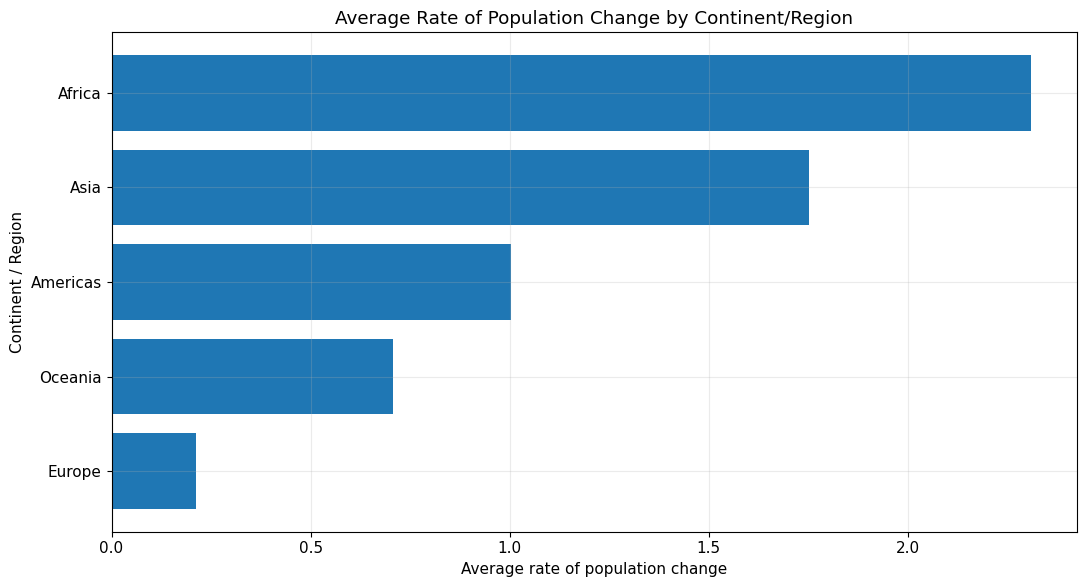

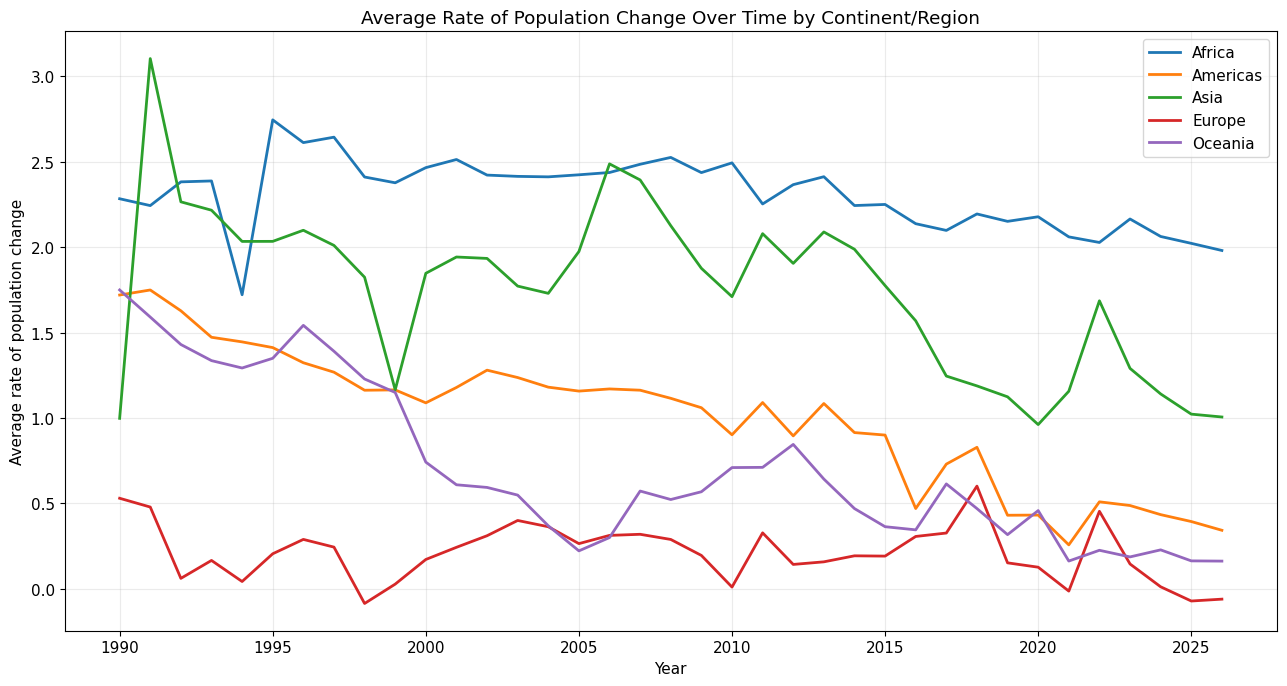

Saved:
- /kaggle/working/population_project_outputs/bar_continent_avg_rate.pdf
- /kaggle/working/population_project_outputs/line_continent_trends.pdf


In [14]:
# 7) Continent comparison charts to satisfy the rubric more directly

# Bar chart: average growth rate by continent/region
plot_continent = continent_summary.sort_values("avg_rate_of_population_change", ascending=True)
plt.figure(figsize=(11, 6))
plt.barh(plot_continent["Continent_or_Region"], plot_continent["avg_rate_of_population_change"])
plt.title("Average Rate of Population Change by Continent/Region")
plt.xlabel("Average rate of population change")
plt.ylabel("Continent / Region")
plt.tight_layout()
continent_bar_path = save_fig("bar_continent_avg_rate.pdf")
plt.show()

# Line chart: continent/region trend over time
plt.figure(figsize=(13, 7))
for cont in continent_yearly_summary["Continent_or_Region"].dropna().unique():
    sub = continent_yearly_summary[continent_yearly_summary["Continent_or_Region"] == cont].sort_values("Year")
    plt.plot(sub["Year"], sub["avg_rate_of_population_change"], linewidth=2, label=cont)
plt.title("Average Rate of Population Change Over Time by Continent/Region")
plt.xlabel("Year")
plt.ylabel("Average rate of population change")
plt.legend(loc="best")
plt.tight_layout()
continent_line_path = save_fig("line_continent_trends.pdf")
plt.show()

print("Saved:")
print("-", continent_bar_path)
print("-", continent_line_path)


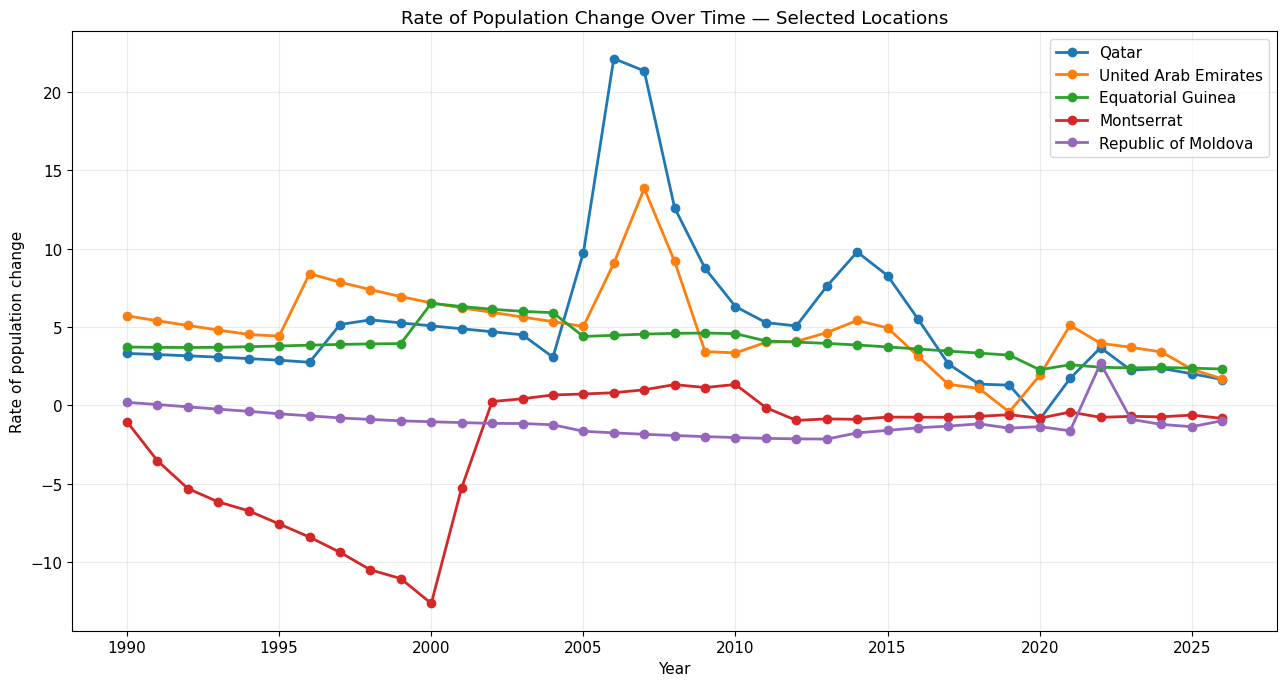

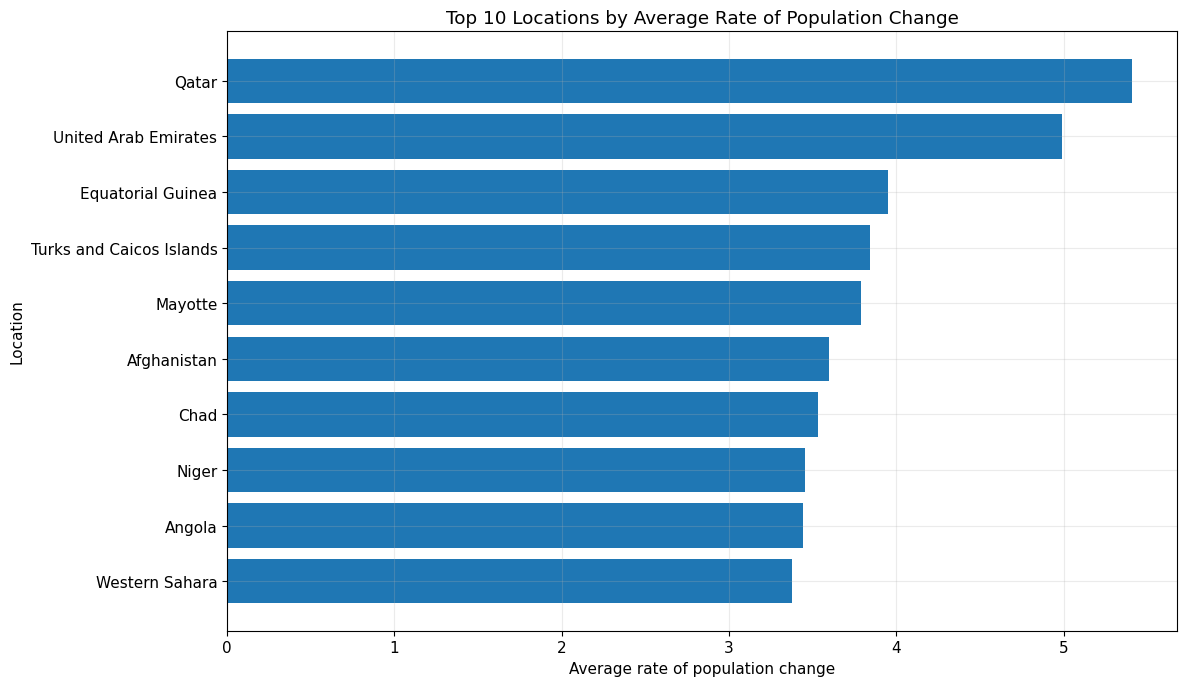

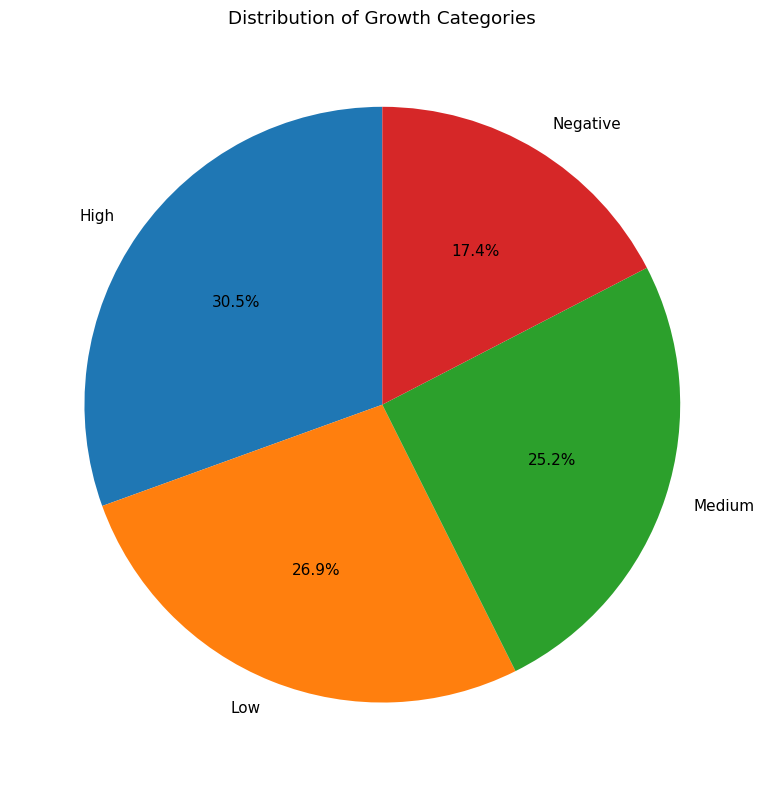

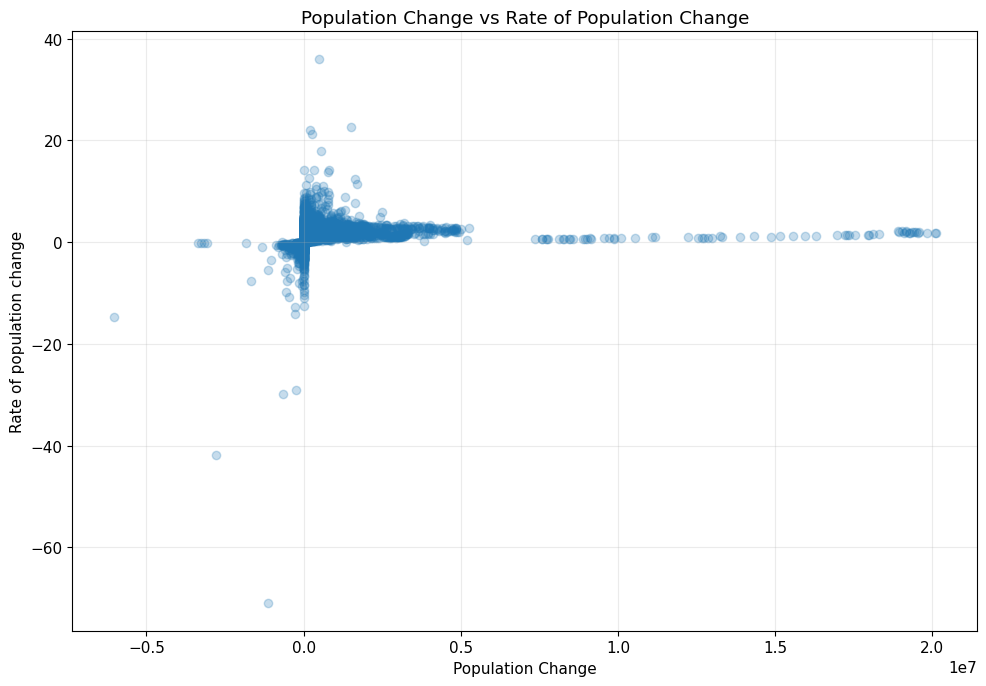

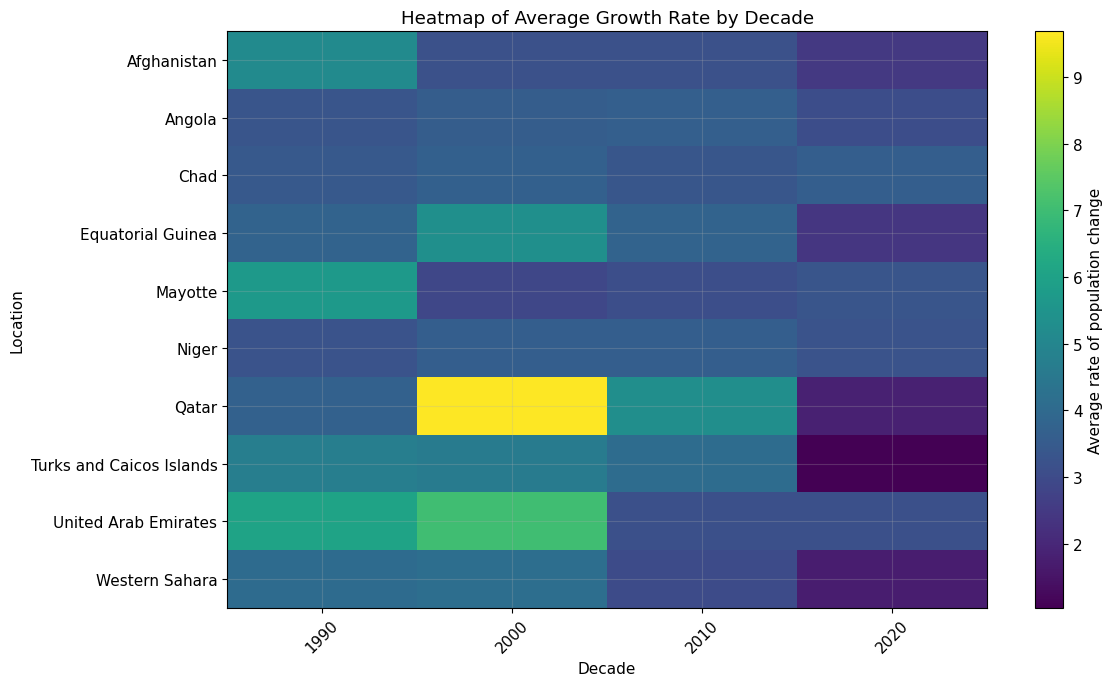

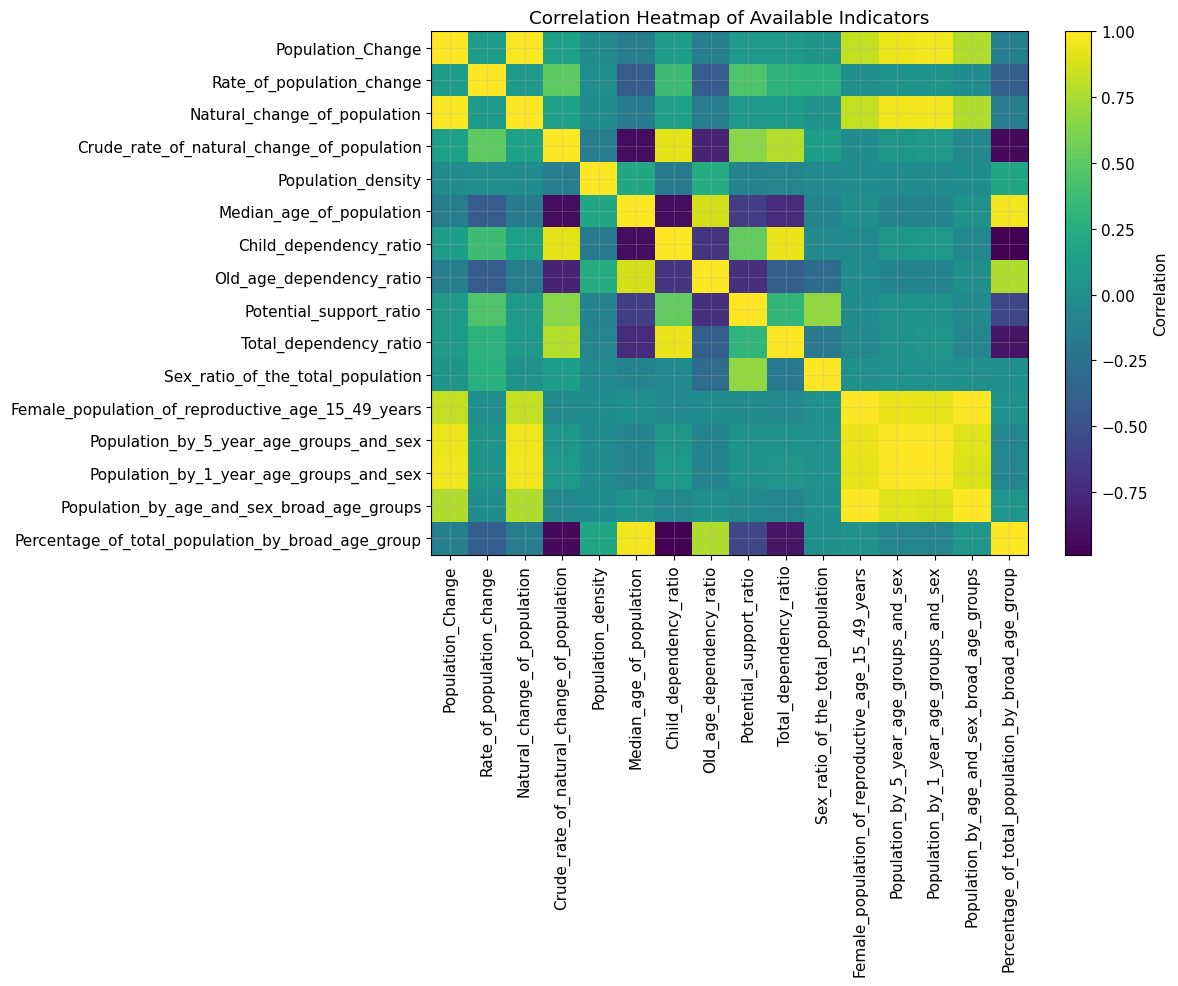

Saved figures:
- /kaggle/working/population_project_outputs/line_rate_of_population_change_selected_locations.pdf
- /kaggle/working/population_project_outputs/bar_top10_avg_rate.pdf
- /kaggle/working/population_project_outputs/pie_growth_category_distribution.pdf
- /kaggle/working/population_project_outputs/scatter_population_change_vs_rate.pdf
- /kaggle/working/population_project_outputs/heatmap_avg_rate_by_decade.pdf
- /kaggle/working/population_project_outputs/heatmap_indicator_correlations.pdf


In [15]:
# Visualizations (all saved as PDF)

# 1) Line chart for selected locations
plt.figure(figsize=(13, 7))
for loc in selected_locations:
    sub = wide[wide["Location"] == loc].sort_values("Year")
    plt.plot(sub["Year"], sub["Rate_of_population_change"], marker="o", linewidth=2, label=loc)
plt.title("Rate of Population Change Over Time — Selected Locations")
plt.xlabel("Year")
plt.ylabel("Rate of population change")
plt.legend(loc="best")
plt.tight_layout()
path1 = save_fig("line_rate_of_population_change_selected_locations.pdf")
plt.show()

# 2) Bar chart: top 10 average growth rate
plot_top10 = top10_rate.sort_values("avg_rate_of_population_change", ascending=True)
plt.figure(figsize=(12, 7))
plt.barh(plot_top10["Location"], plot_top10["avg_rate_of_population_change"])
plt.title("Top 10 Locations by Average Rate of Population Change")
plt.xlabel("Average rate of population change")
plt.ylabel("Location")
plt.tight_layout()
path2 = save_fig("bar_top10_avg_rate.pdf")
plt.show()

# 3) Pie chart: growth category distribution
plt.figure(figsize=(8, 8))
plt.pie(
    growth_category_table["count"],
    labels=growth_category_table["growth_category"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Distribution of Growth Categories")
plt.tight_layout()
path3 = save_fig("pie_growth_category_distribution.pdf")
plt.show()

# 4) Scatter plot: absolute change vs rate of population change
scatter_df = wide[["Population_Change", "Rate_of_population_change"]].dropna()
plt.figure(figsize=(10, 7))
plt.scatter(scatter_df["Population_Change"], scatter_df["Rate_of_population_change"], alpha=0.25)
plt.title("Population Change vs Rate of Population Change")
plt.xlabel("Population Change")
plt.ylabel("Rate of population change")
plt.tight_layout()
path4 = save_fig("scatter_population_change_vs_rate.pdf")
plt.show()

# 5) Heatmap: average rate by decade for selected top locations
heat_locations = top10_rate.head(10)["Location"].tolist()
heat = wide[wide["Location"].isin(heat_locations)].copy()
heat["Decade"] = (heat["Year"] // 10) * 10
heat_pivot = heat.pivot_table(index="Location", columns="Decade", values="Rate_of_population_change", aggfunc="mean")
plt.figure(figsize=(12, 7))
plt.imshow(heat_pivot, aspect="auto")
plt.colorbar(label="Average rate of population change")
plt.xticks(range(len(heat_pivot.columns)), heat_pivot.columns, rotation=45)
plt.yticks(range(len(heat_pivot.index)), heat_pivot.index)
plt.title("Heatmap of Average Growth Rate by Decade")
plt.xlabel("Decade")
plt.ylabel("Location")
plt.tight_layout()
path5 = save_fig("heatmap_avg_rate_by_decade.pdf")
plt.show()

# 6) Correlation heatmap for indicators
plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Heatmap of Available Indicators")
plt.tight_layout()
path6 = save_fig("heatmap_indicator_correlations.pdf")
plt.show()

print("Saved figures:")
for p in [path1, path2, path3, path4, path5, path6]:
    print("-", p)

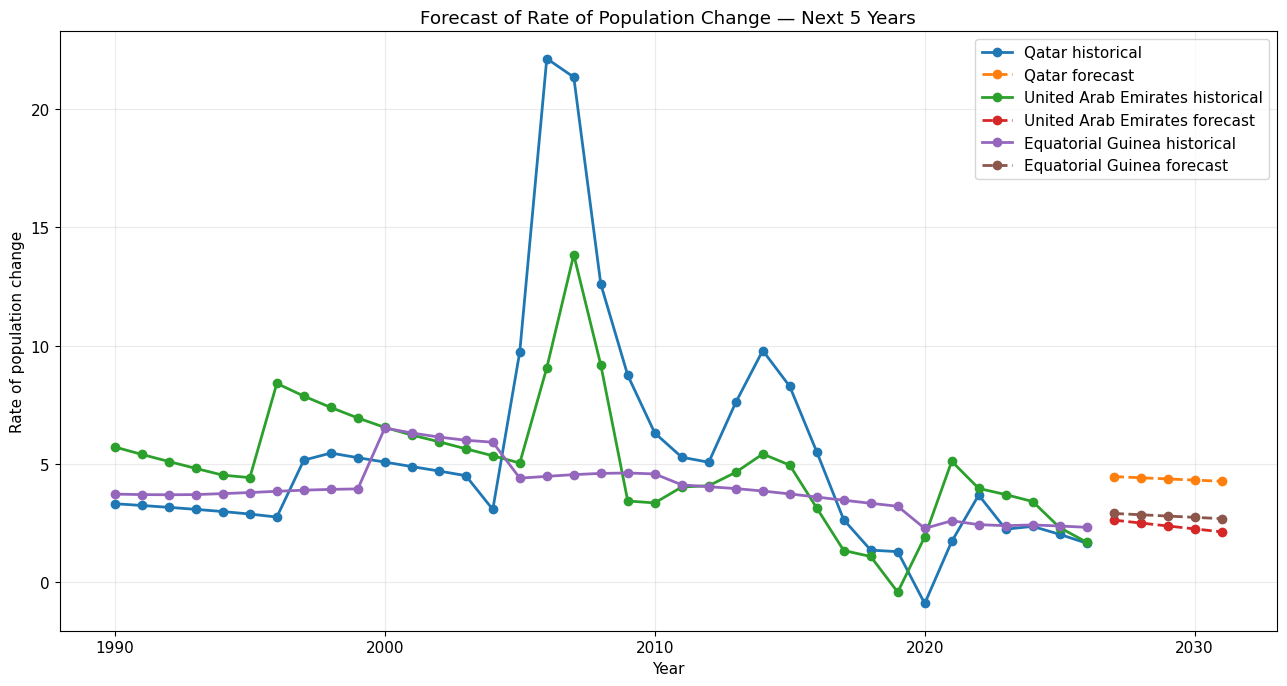

Forecast table:


,Location,Year,Predicted_Rate_of_population_change,Type
0,Qatar,2027,4.464869,Forecast
1,Qatar,2028,4.415315,Forecast
2,Qatar,2029,4.365760,Forecast
3,Qatar,2030,4.316206,Forecast
4,Qatar,2031,4.266651,Forecast
5,United Arab Emirates,2027,2.625770,Forecast
6,United Arab Emirates,2028,2.501478,Forecast
7,United Arab Emirates,2029,2.377186,Forecast
8,United Arab Emirates,2030,2.252893,Forecast
9,United Arab Emirates,2031,2.128601,Forecast



Saved:
- /kaggle/working/population_project_outputs/forecast_results_next_5_years.csv
- /kaggle/working/population_project_outputs/forecast_rate_of_population_change_next_5_years.pdf


In [16]:
# Forecasting: next 5 years for selected locations using linear regression on year vs rate of population change
forecast_years = 5
forecast_locations = top10_rate.head(3)["Location"].tolist()

forecast_frames = []
plt.figure(figsize=(13, 7))

for loc in forecast_locations:
    sub = wide[wide["Location"] == loc][["Year", "Rate_of_population_change"]].dropna().sort_values("Year")
    if len(sub) < 3:
        continue

    X = sub[["Year"]].values
    y = sub["Rate_of_population_change"].values

    model = LinearRegression()
    model.fit(X, y)

    future_years = np.arange(int(sub["Year"].max()) + 1, int(sub["Year"].max()) + forecast_years + 1)
    future_pred = model.predict(future_years.reshape(-1, 1))

    hist_plot = sub.copy()
    hist_plot["Type"] = "Historical"
    hist_plot["Predicted_Rate"] = hist_plot["Rate_of_population_change"]

    fut_plot = pd.DataFrame({
        "Location": loc,
        "Year": future_years,
        "Predicted_Rate_of_population_change": future_pred,
        "Type": "Forecast"
    })
    forecast_frames.append(fut_plot)

    plt.plot(sub["Year"], sub["Rate_of_population_change"], marker="o", linewidth=2, label=f"{loc} historical")
    plt.plot(future_years, future_pred, linestyle="--", marker="o", linewidth=2, label=f"{loc} forecast")

forecast_table = pd.concat(forecast_frames, ignore_index=True) if forecast_frames else pd.DataFrame()
forecast_path = save_table(forecast_table, "forecast_results_next_5_years.csv", index=False)

plt.title("Forecast of Rate of Population Change — Next 5 Years")
plt.xlabel("Year")
plt.ylabel("Rate of population change")
plt.legend(loc="best")
plt.tight_layout()
forecast_fig_path = save_fig("forecast_rate_of_population_change_next_5_years.pdf")
plt.show()

print("Forecast table:")
display(forecast_table)

print("\nSaved:")
print("-", forecast_path)
print("-", forecast_fig_path)

In [17]:
# Final project summary for submission clarity
summary_stats = pd.DataFrame({
    "Metric": [
        "Rows in raw dataset",
        "Unique locations",
        "Year range",
        "Unique indicators",
        "Clean long table rows",
        "Wide analysis table rows",
        "Countries/locations with negative growth years",
        "Forecast locations",
        "Forecast horizon"
    ],
    "Value": [
        len(raw),
        raw["Location"].nunique(),
        f'{int(raw["Time"].min())}–{int(raw["Time"].max())}',
        raw["IndicatorName"].nunique(),
        len(clean_long),
        len(wide),
        int((country_summary["negative_years"] > 0).sum()),
        ", ".join(forecast_locations),
        f"{forecast_years} years"
    ]
})

display(summary_stats)

print("\nSubmission-ready message:")
print("This notebook now includes data audit, cleaning, EDA, advanced analysis, visualizations, forecasting,")
print("continent/region comparison, saved CSV outputs, and PDF figures for report/presentation use.")

,Metric,Value
0,Rows in raw dataset,139712
1,Unique locations,236
2,Year range,1990–2026
3,Unique indicators,16
4,Clean long table rows,139712
5,Wide analysis table rows,8695
6,Countries/locations with negative growth years,127
7,Forecast locations,"Qatar, United Arab Emirates, Equatorial Guinea"
8,Forecast horizon,5 years



Submission-ready message:
This notebook now includes data audit, cleaning, EDA, advanced analysis, visualizations, forecasting,
continent/region comparison, saved CSV outputs, and PDF figures for report/presentation use.


## Results summary you can use in the report

The dataset contains **139,712 records**, covering **236 locations** from **1990 to 2026**, with **16 population-related indicators**. That is strong enough for the project rubric because it exceeds the minimum requirements for both country coverage and time coverage.

The analysis section is complete in four layers. First, the notebook performs data cleaning and reshaping. Second, it completes EDA with yearly summaries, top and bottom locations, negative-growth cases, and continent/region comparisons. Third, it adds advanced analysis using outlier detection, long-term growth ranking, absolute-versus-percentage growth comparison, doubling-time estimates, and indicator correlation. Finally, it creates multiple charts and a 5-year forecast for selected locations.

The main conclusion is that population growth patterns vary widely across locations. Some locations show sustained high growth, while others show low or even negative growth. The forecast section should be described as a **trend-based estimate**, not a perfect prediction, because population dynamics depend on migration, policy, fertility, mortality, and shocks that a simple linear model cannot fully capture.

For presentation, the strongest talking points are:
- why this dataset was chosen,
- how the data was cleaned and reshaped,
- which locations and continents grew fastest,
- where negative growth appears,
- what the outliers mean,
- and why the forecasting method is limited but still useful.

## Final submission notes

### Main improvements made
- Added a **continent/region grouping** column so the notebook matches the rubric more closely.
- Corrected the geography mapping for edge cases such as **Czechia** and **United Republic of Tanzania**.
- Added **continent-level summaries** and comparison charts.
- Kept the notebook honest about the dataset limitation: it is a **population indicators** dataset, not a direct total-population table.
- Preserved the full workflow: audit, cleaning, EDA, advanced analysis, visualizations, forecasting, and exported outputs.

### Key limitation to mention in your report
The source dataset does not include a direct **total population by country-year** column. The notebook therefore uses **Population Change** and **Rate of population change** as the main growth measures, which is appropriate for a growth-analysis project but should be stated clearly in the report.

### What to submit
- This notebook
- Cleaned dataset CSV files from the output folder
- Original dataset
- PDF or Word report
- Presentation slides

### Submission verdict
This version is ready to submit as a stronger, rubric-aligned project notebook.

In [18]:
# Final manifest
manifest = pd.DataFrame({
    "file": sorted([f for f in os.listdir(OUTDIR) if os.path.isfile(os.path.join(OUTDIR, f))])
})
manifest_path = save_table(manifest, "output_manifest.csv", index=False)

print("All generated output files:")
display(manifest)

print("\nOutput folder:", OUTDIR)
print("Manifest saved to:", manifest_path)

All generated output files:


,file
0,absolute_vs_percentage_growth.csv
1,audit_summary.csv
2,bar_continent_avg_rate.pdf
3,bar_top10_avg_rate.pdf
4,bottom10_locations_by_avg_rate.csv
5,clean_long_population_indicators.csv
6,continent_summary.csv
7,continent_yearly_summary.csv
8,country_summary.csv
9,estimated_doubling_time.csv



Output folder: /kaggle/working/population_project_outputs
Manifest saved to: /kaggle/working/population_project_outputs/output_manifest.csv
